## 0. Overview

As part of a collaboration, teams from Crédit Agricole CIB and Quandela have developed a hybrid classical-quantum model to classify [fallen angels](https://www.investopedia.com/terms/f/fallenangel.asp) from a credit scoring dataset. In simple terms, a fallen angel is a bond that used to be safe, but that is now risky (its quality decreased). However, the dataset used in the original project is private, so we will instead work, in this notebook, with an open-source dataset on company bankruptcy prediction. This task is similar to fallen angel classification in many ways:
- Modelization of a regime change (from healty to unhealthy)
- Time dependent
- Goal of detecting early warning signs
- Imbalanced dataset (bankruptcy and fallen angels are rarer than their counterpart)
- Similar feature space that relies on economic metrics

The [specific dataset](https://www.kaggle.com/datasets/fedesoriano/company-bankruptcy-prediction) we use is a bankruptcy dataset from the Taiwan Economic Journal (1999-2009). A [notebook on prediction for this dataset](https://www.kaggle.com/code/ahmedtronic/company-bankruptcy-prediction) is also presented, which helped with the construction of this current notebook.

# Bankruptcy Prediction Tutorial
(CA CIB and Quandela teams solution)



## 1. Imports

All imports and handdling of random seeds.

In [ ]:
import matplotlib.pyplot as plt
import merlin as ML
import numpy as np
import os
import pandas as pd
import random
import torch
from imblearn.over_sampling import RandomOverSampler
from scipy.optimize import minimize
from scipy.special import expit
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.decomposition import PCA
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import auc, precision_recall_curve, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from tqdm.auto import tqdm

# Deterministic setup
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## 2. Dataset

We will fetch the bankruptcy prediction dataset from [Kaggle](https://www.kaggle.com), an online platform to share datasets, build and run machine learning models, and compete in data science challenges. To access the data, you need to have (or will need to create) an access token on Kaggle. Here are the simple steps to create your access token:
1. Go to [kaggle.com](kaggle.com)
2. Register or sign in if you already have an account
3. Once that is done, click on your profile image in the top right corner
4. Select account
5. Scroll to the API section and click on "Create New Token"

This should trigger a download of a file called `kaggle.json` containing your username and API key.

In this file, copy your API key and set it as a variable in the next cell


In [ ]:
KAGGLE_API_TOKEN="{YOUR_KAGGLE_API_TOKEN}"

Next we install kaggle.

In [3]:
!pip install kaggle


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


We can now access the dataset and download it locally. This cell should download a zip file called `american-companies-bankruptcy-prediction-dataset.zip`.

In [4]:
!kaggle datasets download -d fedesoriano/company-bankruptcy-prediction

Dataset URL: https://www.kaggle.com/datasets/fedesoriano/company-bankruptcy-prediction
License(s): copyright-authors
100%|██████████████████████████████████████| 4.63M/4.63M [00:01<00:00, 4.73MB/s]



We unzip this file to obtain the dataset.

In [5]:
!unzip company-bankruptcy-prediction.zip

Archive:  company-bankruptcy-prediction.zip
  inflating: data.csv                


We finally have our dataset locally. We now need to preprocess it before moving on to the model implementation.

In [241]:
df = pd.read_csv("./data.csv")
df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


Exploration of the dataset:

In [242]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Interest Rate 

We look at the number of missing data.

In [243]:
(df.isna().sum() > 0).sum()

np.int64(0)

So no data is missing.

Next, we look at the count for each label (0: healthy, 1: bankrupt).

Bankrupt?
0    0.967737
1    0.032263
Name: proportion, dtype: float64


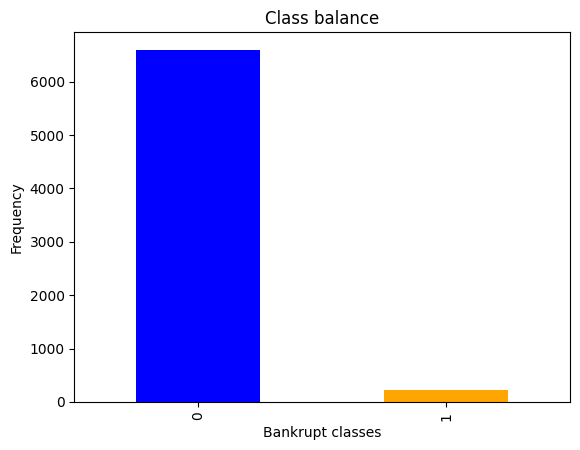

In [244]:
df['Bankrupt?'].value_counts().plot(kind= 'bar', color = ['blue', 'orange'])
plt.xlabel("Bankrupt classes")
plt.ylabel("Frequency")
plt.title("Class balance")
print(df['Bankrupt?'].value_counts(normalize=True))

### 2.1 Dataset Splits

Now, we separate the dataset into three sets: the train, validation and the test sets.


In [245]:
target = "Bankrupt?"
X = df.drop(columns=[target])
y = df[target]

print(f"Before splitting: {X.shape}, {y.shape}")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

# We then split test set into validation and test sets
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")


Before splitting: (6819, 95), (6819,)
X_train shape: (4773, 95), y_train shape: (4773,)
X_val shape: (1023, 95), y_val shape: (1023,)
X_test shape: (1023, 95), y_test shape: (1023,)


### 2.2 Oversampling

We apply oversampling to reduce the effect of the dataset labels imbalancement during training.


In [246]:
ros = RandomOverSampler(random_state=42)
X_train, y_train = ros.fit_resample(X_train, y_train)
print(f"After resampling: {X_train.shape}, {y_train.shape}")
print(f"Class distribution after resampling:\n{pd.Series(y_train).value_counts(normalize=True)}")


After resampling: (9262, 95), (9262,)
Class distribution after resampling:
Bankrupt?
0    0.5
1    0.5
Name: proportion, dtype: float64


### 2.3 Standardization

Next, we want to standardize our data as preprocessing. That is to induce mean = 0 and variance = 1 to every feature of the training set (and applying the same transformation to the validation and test sets).


In [247]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

X_train.mean(axis=0), X_train.std(axis=0)

(array([ 1.96392723e-16, -6.87374532e-16, -7.85570893e-16,  2.92134176e-15,
        -3.16683266e-15, -2.22491475e-14, -2.72494904e-15, -4.31757128e-15,
         4.43724809e-15,  1.51590633e-15, -1.53431815e-17, -9.20590891e-17,
        -2.08667269e-15,  0.00000000e+00, -1.22745452e-16,  9.81963617e-17,
        -4.41883628e-16, -2.45490904e-16,  0.00000000e+00,  8.10119984e-16,
        -6.13727260e-18, -2.45490904e-16,  4.41883628e-16, -8.13188620e-17,
        -1.00774016e-14,  3.35708811e-15,  4.90981808e-15,  2.12656496e-15,
         2.45490904e-17, -1.53431815e-18, -2.22476132e-15,  8.34669074e-16,
         1.22745452e-17,  0.00000000e+00,  4.07284753e-15, -1.22745452e-17,
        -9.81963617e-17,  2.94589085e-16,  5.52354534e-17, -8.59218165e-17,
         9.20590891e-17,  1.71843633e-16,  1.96392723e-16, -3.68236356e-16,
         1.22745452e-17, -7.47980099e-18, -1.53431815e-18, -1.01264998e-16,
         4.90981808e-17,  4.29609082e-17, -6.13727260e-18,  6.62825441e-16,
        -3.0

### 2.4 Build The Dataset

Now that our original features are preprocessed, we will use [Principle Component Analysis](https://en.wikipedia.org/wiki/Principal_component_analysis) to only consider 5 features instead of 18 to mimic the original fallen angel prediction framework which presented 5 features.


In [248]:
pca = PCA(n_components=5)
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

X_train_pca.shape, X_val_pca.shape, X_test_pca.shape

((9262, 5), (1023, 5), (1023, 5))

In [249]:
pca.explained_variance_ratio_

array([0.16948571, 0.07214918, 0.0653974 , 0.05641544, 0.04374511])

Since there are 95 features, it is normal to lose a big part of the original dataset variance by using PCA to reduce dimentionality to 5.

### 2.5 Angle Encoding

In the original implementation, quantum models use an angle-like preprocessing before before entering photonic circuits through angle encoding.
Each feature is transformed with a sigmoid rescaling into `[0, pi]`, using train-set statistics.

We apply this preprocessing to the dataset now, for later use in the hybrid model.



In [250]:
def transform_features_to_phases(x, means=None, stds=None):
    """Feature-to-phase transform: pi / (1 + exp(-(x-mean)/std))."""
    x = np.asarray(x, dtype=np.float32)

    if means is None:
        means = x.mean(axis=0)
    if stds is None:
        stds = x.std(axis=0)

    stds = np.where(stds < 1e-12, 1.0, stds)
    z = (x - means) / stds
    #phases = np.pi / (1.0 + np.exp(-z))
    phases = np.pi * expit(z)  # more stable version
    return phases, means, stds

X_train_pca_angle, pca_angle_means, pca_angle_stds = transform_features_to_phases(X_train_pca)
X_val_pca_angle, _, _ = transform_features_to_phases(X_val_pca, pca_angle_means, pca_angle_stds)
X_test_pca_angle, _, _ = transform_features_to_phases(X_test_pca, pca_angle_means, pca_angle_stds)


## 3. Model Definitions

We define two models:
1. **Classical AdaBoost** (baseline).
2. **Quantum-Enhanced AdaBoost** which comprises of several branches:
   - The first branch send the input through the classical AdaBoost model
   - The remaining branches send the input through k different Quantum Classifiers
Afterward, the final score is an optimized weighted sum of the obtained scores from every branch.

The quantum classifiers are made of fixed (non-trainable) quantum circuits followed by a trainable linear readout.


In [251]:
class ClassicalAdaBoost:
    def __init__(self, n_estimators=50, max_depth=3, random_state=42):
        base_tree = DecisionTreeClassifier(max_depth=max_depth, random_state=random_state)
        self.model = AdaBoostClassifier(
            estimator=base_tree,
            n_estimators=n_estimators,
            random_state=10,
        )

    def fit(self, x_train, y_train):
        self.model.fit(x_train, y_train)

    def predict(self, x):
        return self.model.predict(x)

    def predict_proba(self, x):
        return self.model.predict_proba(x)[:, 1]

Next we define the quantum classifier model class:

In [252]:
class QuantumClassifier(torch.nn.Module):
    """
    A simple quantum classifier model that consists of a trainable quantum layer followed by a trainable linear readout.
    """
    def __init__(self, n_features=5):
        super().__init__()
        self.n_features = n_features
        self.quantum_layer = self.create_quantum_layer()
        self.readout = torch.nn.Linear(self.quantum_layer.output_size, 1)
        self.readout

    def create_quantum_layer(self):
        builder = ML.CircuitBuilder(n_modes=self.n_features)
        # Start by placing an entangling layer
        builder.add_entangling_layer(modes=[0, self.n_features - 1], trainable=True)
        # Encode the data using angle encoding on all modes
        builder.add_angle_encoding(modes=list(range(self.n_features)), name="data")
        # Add another entangling layer after the encoding
        builder.add_entangling_layer(modes=[0, self.n_features - 1], trainable=True)

        # Define quantum layer
        quantum_layer = ML.QuantumLayer(
            builder=builder,
            input_state=[1, 0, 1, 0, 0],
            measurement_strategy=ML.MeasurementStrategy.probs(computation_space=ML.ComputationSpace.FOCK),
        )
        return quantum_layer

    def forward(self, x):
        """
        It is assumed here that the input x is already "angle transformed"
        """
        assert len(x.shape) == 2, "Input must be a 2D tensor of shape (n_samples, n_features)"
        n_sample = x.shape[0]
        n_features = x.shape[1]
        assert n_features == self.n_features, f"Expected {self.n_features} features, got {n_features}"

        # Assume x is already in angle-encoded form
        q_out = self.quantum_layer(x)
        q_score = torch.sigmoid(self.readout(q_out))

        assert q_score.shape == (n_sample, 1), f"Expected output shape (n_samples, 1), got {q_score.shape}"
        return q_score.squeeze()

In [253]:
# Check that the number of parameters fits the expected number for the defined quantum layer and readout
qc = QuantumClassifier(n_features=5)
total_params = sum(p.numel() for p in qc.parameters())
print(f"Total parameters in QuantumClassifier: {total_params}")

circuit_params = sum(p.numel() for p in qc.quantum_layer.parameters())
expected_params = circuit_params + qc.quantum_layer.output_size + 1  # circuit params +readout weights + bias
print(f"Expected parameters (circuit params + readout weights + bias): {expected_params}")
assert total_params == expected_params, f"Expected {expected_params} parameters, but got {total_params}"

Total parameters in QuantumClassifier: 56
Expected parameters (circuit params + readout weights + bias): 56


Next we move on to the more general QuantumEnhancedAdaBoost model.

It expects at initialization an already fitted classical AdaBoost model and already trained quantum_estimators. 

Some methods for optimization of the ensembling weights are then defined `precision_at_fixed_recall` and `optimize_nonnegative_weights`. These methods are used in the `fit` method which encapsulates all the training for this weight vector. Because the dataset we use here is highly unbalanced, the metric of interest is the precision at a fixed recall of 83%. We can interpet this as:
- The model correctly identifies 83% of the actual bankruptcy
- Measure precision: among the bankruptcy predictions, how many are correct?

The weight vector (which combines outputs from every submodel) is optimized with regard to this metric.

In [254]:
def precision_at_fixed_recall(y_true, y_scores, target_recall=0.83):
    """
    Get maximum precision at recall >= target_recall.
    If no recall value is above target_recall, return NaN.
    """
    precision, recall, _ = precision_recall_curve(y_true, y_scores)

    mask = recall >= target_recall
    if not np.any(mask):
        return np.nan

    return float(np.max(precision[mask]))

In the hybrid model (QuantumEnhancedAdaBoost), we enforce two constraints on the unifying weights:
1. The sum of the weigth vector must equal 1 to ensure a fusion of scores that does not scale.
2. Each weight value must be positive to ensure every submodel is used as intended for the final prediction.
3. The final optimized value of the weights must be superior to their initial value divised by the number of submodels. That is to ensure no submodel is completelly ignored while giving the complete hybrid model a margin that scales with the number of submodels to choose which submodel to consider with more importance.

In [255]:
class QuantumEnhancedAdaBoost(BaseEstimator, ClassifierMixin):
    def __init__(self, classical_model, quantum_estimators):
        """
        Initializes the QuantumEnhancedAdaBoost model.

        Args:
            classical_model: The fitted classical AdaBoost model.
            quantum_estimators: A list of already trained quantum estimators to be used.
        """
        self.classical_model = classical_model
        self.quantum_estimators = quantum_estimators
        self.n_quantum = len(quantum_estimators)
        self.weights = np.ones(self.n_quantum + 1) / (self.n_quantum + 1)  # Initialize weights equally

    def optimize_nonnegative_weights(self, scores, y_true, target_recall=0.83):
        """
        Optimize non-negative ensemble weights to maximize precision at fixed recall,
        while enforcing a minimum per-component contribution.

        scores shape: (n_components, n_samples)
        """
        n_components = scores.shape[0]
        init = self.weights.copy()

        # Constraint: each weight >= initial_value / n_components.
        # With equal initialization, initial_value = 1 / n_components, so min_weight = 1 / n_components^2.
        initial_value = float(init[0])
        min_weight = initial_value / n_components

        # Keep a small safety margin from exact bounds for numerical stability.
        eps = 1e-12
        min_weight = max(0.0, min(min_weight, 1.0 / n_components - eps))

        def objective(w):
            combined_scores = w @ scores
            precision = precision_at_fixed_recall(y_true, combined_scores, target_recall=target_recall)
            if np.isnan(precision):
                return 1e6
            return -precision

        # Feasible initialization inside simplex with lower-bounded components.
        init = np.clip(init, min_weight, None)
        init = init / init.sum()
        if np.any(init < min_weight):
            # If clipping + normalization drifts below bound, rebuild from slack allocation.
            slack = 1.0 - n_components * min_weight
            if slack <= 0:
                init = np.ones(n_components) / n_components
            else:
                extra = np.maximum(self.weights - self.weights.min(), 0.0)
                if extra.sum() == 0:
                    extra = np.ones(n_components)
                extra = extra / extra.sum()
                init = min_weight + slack * extra

        # COBYLA supports inequality constraints only.
        # Enforce sum(w)=1 with two inequalities using a small tolerance.
        eq_tol = 1e-9
        constraints = [
            {"type": "ineq", "fun": lambda w: w - min_weight},
            {"type": "ineq", "fun": lambda w: np.sum(w) - (1.0 - eq_tol)},
            {"type": "ineq", "fun": lambda w: (1.0 + eq_tol) - np.sum(w)},
        ]

        result = minimize(
            objective,
            x0=init,
            method="COBYLA",
            constraints=constraints,
            options={"maxiter": 2000, "tol": 1e-9, "catol": 1e-9},
        )

        if result.success:
            weights = result.x
        else:
            weights = init

        # Final projection for robustness against tiny numerical violations.
        weights = np.clip(weights, min_weight, None)
        weights = weights / weights.sum()
        self.weights = weights
        return

    def fit(self, X, X_angle, y):
        classical_score = self.classical_model.predict_proba(X)
        quantum_scores = [quantum_estimator(torch.tensor(X_angle, dtype=torch.float32)).detach().numpy() for quantum_estimator in self.quantum_estimators]
        scores = np.vstack([classical_score] + quantum_scores)
        assert scores.shape == (self.n_quantum + 1, X.shape[0]), f"Expected scores shape ({self.n_quantum + 1}, n_samples), got {scores.shape}"
        self.optimize_nonnegative_weights(scores, y)

    def predict(self, X, X_angle):
        classical_score = self.classical_model.predict_proba(X)
        quantum_scores = [quantum_estimator(torch.tensor(X_angle, dtype=torch.float32)).detach().numpy() for quantum_estimator in self.quantum_estimators]
        scores = np.vstack([classical_score] + quantum_scores)
        assert scores.shape == (self.n_quantum + 1, X.shape[0]), f"Expected scores shape ({self.n_quantum + 1}, n_samples), got {scores.shape}"
        combined_scores = self.weights @ scores
        return (combined_scores >= 0.5).astype(float)

    def predict_proba(self, X, X_angle):
        classical_score = self.classical_model.predict_proba(X)
        quantum_scores = [quantum_estimator(torch.tensor(X_angle, dtype=torch.float32)).detach().numpy() for quantum_estimator in self.quantum_estimators]
        scores = np.vstack([classical_score] + quantum_scores)
        assert scores.shape == (self.n_quantum + 1, X.shape[0]), f"Expected scores shape ({self.n_quantum + 1}, n_samples), got {scores.shape}"
        combined_scores = self.weights @ scores

        return combined_scores




## 4. Baseline Models

### 4.1 Neural Network
Let us also define a classical Neural Network baseline.


In [256]:
class NeuralNetWork(torch.nn.Module):
    def __init__(self, n_features=5, hidden_size=4):
        super().__init__()
        self.model = torch.nn.Sequential(
            torch.nn.Linear(n_features, hidden_size),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_size, 1),
            torch.nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).squeeze()

### 4.2 K-NN

We define a k-nearest-neighbours classifier.


In [257]:
knn_pca = KNeighborsClassifier(n_neighbors=5)


## 5. Training

The training will be done in several steps.

1. Train the classical AdaBoost model (on the training set)


In [258]:
adaboost_pca = ClassicalAdaBoost()

print("Fitting classical AdaBoost model on PCA dataset...")
adaboost_pca.fit(X_train_pca, y_train)

Fitting classical AdaBoost model on PCA dataset...


We define a function to analyze performance of an sklearn model on the train set and a test set.

In [259]:
def sklearn_model_analysis(model, X_train, y_train, X_test, y_test):
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)

    train_probas = model.predict_proba(X_train)
    test_probas = model.predict_proba(X_test)

    # Handle binary classification case where predict_proba returns shape (n_samples, 2)
    if train_probas.ndim > 1 and train_probas.shape[1] > 1:
        train_probas = train_probas[:, 1]
    if test_probas.ndim > 1 and test_probas.shape[1] > 1:
        test_probas = test_probas[:, 1]

    train_precision = precision_at_fixed_recall(y_train, train_probas, target_recall=0.83)
    test_precision = precision_at_fixed_recall(y_test, test_probas, target_recall=0.83)

    print(f"MODEL OUTPUT ANALYSIS:#####################################")
    print(f"Number of positive predictions (class 1.0) on train set: {(train_preds == 1.0).sum()} out of {len(train_preds)}")
    print(f"Number of positive predictions (class 1.0) on test set: {(test_preds == 1.0).sum()} out of {len(test_preds)}")
    print(f"\nTRAIN METRICS:#####################################")
    print(f"Accuracy: {(train_preds == y_train).mean():.4f}, Precision at 83% recall: {train_precision:.4f}")
    print(f"\nTEST METRICS:#####################################")
    print(f"Accuracy: {(test_preds == y_test).mean():.4f}, Precision at 83% recall: {test_precision:.4f}")

    only_zero = np.array([0.0] * len(y_test))
    only_one = np.array([1.0] * len(y_test))
    random_outputs = np.random.rand(len(y_test))
    random_preds = (random_outputs >= 0.5).astype(float)

    accuracy_only_zero = np.mean(only_zero == y_test)
    accuracy_only_one = np.mean(only_one == y_test)
    accuracy_random = np.mean(random_preds == y_test)

    precision_random = precision_at_fixed_recall(y_test, random_outputs, target_recall=0.83)
    print(f"\nTRIVIAL BASELINE TEST METRICS:#####################################")
    print(f"Test accuracy (only zeros): {accuracy_only_zero:.4f}")
    print(f"Test accuracy (only ones): {accuracy_only_one:.4f}")
    print(f"Test accuracy (random): {accuracy_random:.4f}, Precision at 83% recall (random) on test: {precision_random:.4f}")


### 5.1 AdaBoost Output And Performance Analysis (Train And Validation)


In [260]:
sklearn_model_analysis(adaboost_pca, X_train_pca, y_train, X_val_pca, y_val)

MODEL OUTPUT ANALYSIS:#####################################
Number of positive predictions (class 1.0) on train set: 5010 out of 9262
Number of positive predictions (class 1.0) on test set: 133 out of 1023

TRAIN METRICS:#####################################
Accuracy: 0.9496, Precision at 83% recall: 0.9706

TEST METRICS:#####################################
Accuracy: 0.8847, Precision at 83% recall: 0.1162

TRIVIAL BASELINE TEST METRICS:#####################################
Test accuracy (only zeros): 0.9619
Test accuracy (only ones): 0.0381
Test accuracy (random): 0.5024, Precision at 83% recall (random) on test: 0.0397


2. Train the quantum classifiers (also on the training set after angle transform)

We start off by defining a function to train torch models.

In [261]:
def train_torch_model(model, X_angle, y, n_epochs=50, lr=1e-2, batch_size=64):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=25, gamma=0.1)
    criterion = torch.nn.BCELoss()
    
    dataset = torch.utils.data.TensorDataset(torch.tensor(X_angle, dtype=torch.float32), torch.tensor(y, dtype=torch.float32))
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model.train()

    train_losses = []
    train_accuracies = []

    progress = tqdm(range(n_epochs), desc="Training", leave=False)
    for epoch in progress:
        epoch_loss = 0.0
        epoch_correct = 0
        epoch_total = 0

        for batch_X, batch_y in dataloader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * batch_X.size(0)
            preds = (outputs >= 0.5).float()
            epoch_correct += (preds == batch_y).sum().item()
            epoch_total += batch_y.size(0)

        scheduler.step()

        epoch_loss /= len(dataset)
        epoch_acc = epoch_correct / epoch_total if epoch_total > 0 else 0.0

        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)

        progress.set_postfix(loss=f"{epoch_loss:.4f}", acc=f"{epoch_acc:.4f}")
        if epoch % 10 == 0 or epoch == n_epochs - 1:
            print(f"Epoch {epoch + 1:03d}/{n_epochs} | Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f}")

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label="Train Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

    return {"train_loss": train_losses, "train_accuracy": train_accuracies}

Training quantum classifiers on PCA dataset...


Training:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 001/50 | Train Loss: 0.6240 | Train Acc: 0.7125
Epoch 011/50 | Train Loss: 0.3826 | Train Acc: 0.8446
Epoch 021/50 | Train Loss: 0.3698 | Train Acc: 0.8486
Epoch 031/50 | Train Loss: 0.3616 | Train Acc: 0.8501
Epoch 041/50 | Train Loss: 0.3610 | Train Acc: 0.8522
Epoch 050/50 | Train Loss: 0.3603 | Train Acc: 0.8537


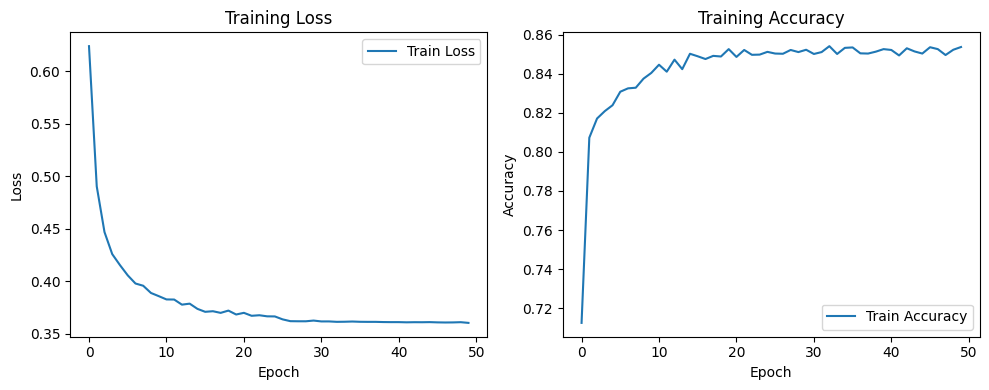

Trained quantum classifier 1/3 on PCA dataset.


Training:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 001/50 | Train Loss: 0.6005 | Train Acc: 0.7606
Epoch 011/50 | Train Loss: 0.3878 | Train Acc: 0.8437
Epoch 021/50 | Train Loss: 0.3769 | Train Acc: 0.8453
Epoch 031/50 | Train Loss: 0.3712 | Train Acc: 0.8436
Epoch 041/50 | Train Loss: 0.3706 | Train Acc: 0.8447
Epoch 050/50 | Train Loss: 0.3701 | Train Acc: 0.8456


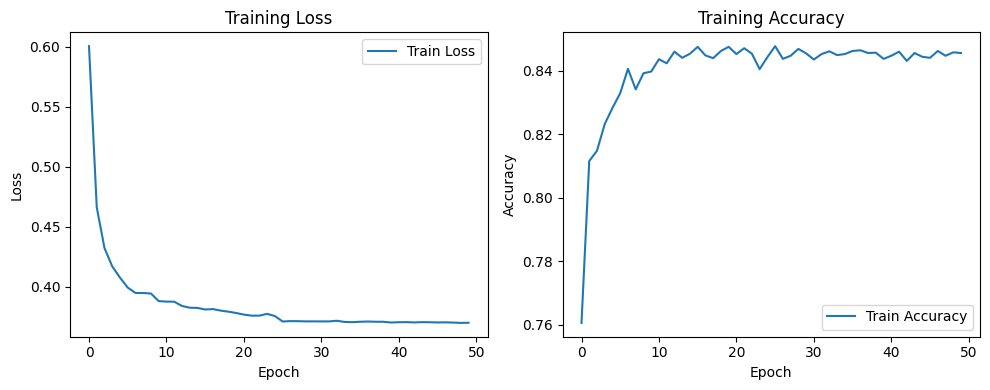

Trained quantum classifier 2/3 on PCA dataset.


Training:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 001/50 | Train Loss: 0.5938 | Train Acc: 0.7495
Epoch 011/50 | Train Loss: 0.3983 | Train Acc: 0.8358
Epoch 021/50 | Train Loss: 0.3818 | Train Acc: 0.8442
Epoch 031/50 | Train Loss: 0.3699 | Train Acc: 0.8472
Epoch 041/50 | Train Loss: 0.3689 | Train Acc: 0.8482
Epoch 050/50 | Train Loss: 0.3681 | Train Acc: 0.8484


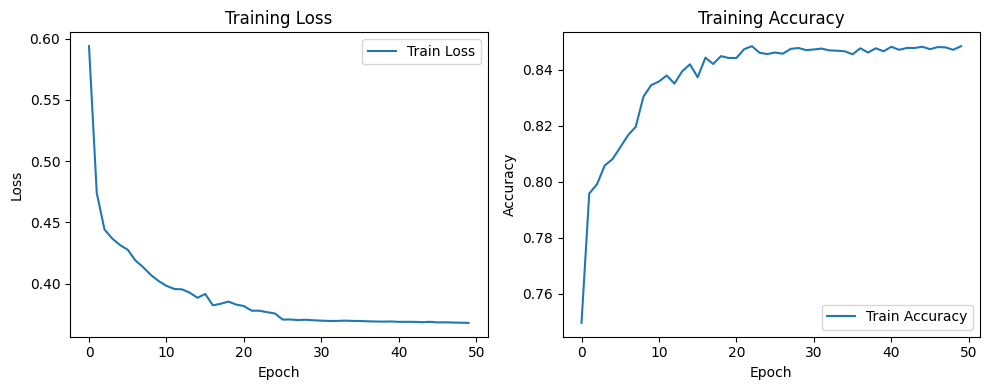

Trained quantum classifier 3/3 on PCA dataset.


In [262]:
# Choose number of quantum classifiers
n_quantum_classifiers = 3
# Initialize quantum classifiers
quantum_classifiers_pca = [QuantumClassifier() for _ in range(n_quantum_classifiers)]

# Select datasets
X_train_pca_quantum = X_train_pca_angle
X_val_pca_quantum = X_val_pca_angle
X_test_pca_quantum = X_test_pca_angle
y_train = np.array(y_train, dtype=np.float32)
y_test = np.array(y_test, dtype=np.float32)

# Train quantum classifiers on PCA dataset
print("Training quantum classifiers on PCA dataset...")
for i, quantum_classifier_pca in enumerate(quantum_classifiers_pca):
    train_torch_model(quantum_classifier_pca, X_train_pca_quantum, y_train)
    print(f"Trained quantum classifier {i+1}/{n_quantum_classifiers} on PCA dataset.")


We define a function to print an analysis of a torch model's output and performance metrics.

In [263]:
def torch_model_analysis(torch_model, X_train, y_train, X_test, y_test):
    torch_model.eval()
    with torch.no_grad():
        train_outputs = torch_model(torch.tensor(X_train, dtype=torch.float32)).numpy()
        test_outputs = torch_model(torch.tensor(X_test, dtype=torch.float32)).numpy()

    print("MODEL OUTPUTS ANALYSIS: ###################################################")
    print(f"Train outputs - min: {train_outputs.min():.4f}, max: {train_outputs.max():.4f}, mean: {train_outputs.mean():.4f}, std: {train_outputs.std():.4f}")
    print(f"Number of unique output values on train set of length {len(train_outputs)}: {len(np.unique(train_outputs))}")
    if len(np.unique(train_outputs)) < 6:
        print(f"Warning: Low number of unique output values; output values all in {np.unique(train_outputs)}")
    print(f"Test outputs - min: {test_outputs.min():.4f}, max: {test_outputs.max():.4f}, mean: {test_outputs.mean():.4f}, std: {test_outputs.std():.4f}")
    print(f"Number of unique output values on test set of length {len(test_outputs)}: {len(np.unique(test_outputs))}")
    if len(np.unique(test_outputs)) < 6:
        print(f"Warning: Low number of unique output values; output values all in {np.unique(test_outputs)}")

    train_predictions = (train_outputs >= 0.5).astype(float)
    test_predictions = (test_outputs >= 0.5).astype(float)

    train_accuracy = np.mean(train_predictions == y_train)
    test_accuracy = np.mean(test_predictions == y_test)

    train_precision = precision_at_fixed_recall(y_train, train_outputs, target_recall=0.83)
    test_precision = precision_at_fixed_recall(y_test, test_outputs, target_recall=0.83)

    print("\nMODEL PERFORMANCE ANALYSIS: ###################################################")
    print(f"Training accuracy: {train_accuracy:.4f}, Precision at 83% recall: {train_precision:.4f}")
    print(f"Test accuracy: {test_accuracy:.4f}, Precision at 83% recall: {test_precision:.4f}")

    only_zero = np.array([0.0] * len(y_test))
    only_one = np.array([1.0] * len(y_test))
    random_outputs = np.random.rand(len(y_test))
    random_preds = (random_outputs >= 0.5).astype(float)

    accuracy_only_zero = np.mean(only_zero == y_test)
    accuracy_only_one = np.mean(only_one == y_test)
    accuracy_random = np.mean(random_preds == y_test)

    precision_random = precision_at_fixed_recall(y_test, random_outputs, target_recall=0.83)
    print(f"\nTRIVIAL PREDICTORS TEST PERFORMANCE: ###################################################")
    print(f"Only zero predictor - Test accuracy: {accuracy_only_zero:.4f}")
    print(f"Only one predictor - Test accuracy: {accuracy_only_one:.4f}")
    print(f"Random predictor - Test accuracy: {accuracy_random:.4f}, Precision at 83% recall (on test): {precision_random:.4f}")

### 5.2 First Quantum Classifier Output And Performance Analysis (Train And Validation)


In [264]:
torch_model_analysis(quantum_classifiers_pca[0], X_train_pca_quantum, y_train, X_val_pca_quantum, y_val)

MODEL OUTPUTS ANALYSIS: ###################################################
Train outputs - min: 0.0061, max: 0.9917, mean: 0.5024, std: 0.3591
Number of unique output values on train set of length 9262: 4773
Test outputs - min: 0.0072, max: 0.9904, mean: 0.2637, std: 0.2732
Number of unique output values on test set of length 1023: 1023

MODEL PERFORMANCE ANALYSIS: ###################################################
Training accuracy: 0.8538, Precision at 83% recall: 0.8705
Test accuracy: 0.8221, Precision at 83% recall: 0.2481

TRIVIAL PREDICTORS TEST PERFORMANCE: ###################################################
Only zero predictor - Test accuracy: 0.9619
Only one predictor - Test accuracy: 0.0381
Random predictor - Test accuracy: 0.4966, Precision at 83% recall (on test): 0.0418


### 5.3 Train The NN Baseline


Number of parameters in NN: 29


Training:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 001/50 | Train Loss: 0.4530 | Train Acc: 0.8319
Epoch 011/50 | Train Loss: 0.3788 | Train Acc: 0.8512
Epoch 021/50 | Train Loss: 0.3765 | Train Acc: 0.8475
Epoch 031/50 | Train Loss: 0.3724 | Train Acc: 0.8558
Epoch 041/50 | Train Loss: 0.3723 | Train Acc: 0.8552
Epoch 050/50 | Train Loss: 0.3722 | Train Acc: 0.8538


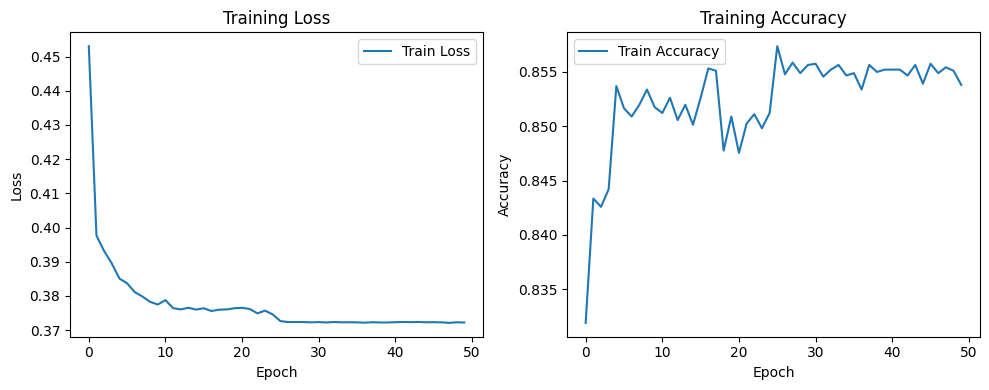

Training of NN baseline completed on PCA dataset.


In [265]:
train_pca_nn = X_train_pca
val_pca_nn = X_val_pca
test_pca_nn = X_test_pca

nn_pca = NeuralNetWork(n_features=train_pca_nn.shape[1], hidden_size=4)
print("Number of parameters in NN:", sum(p.numel() for p in nn_pca.parameters()))
train_torch_model(nn_pca, train_pca_nn, y_train)
print("Training of NN baseline completed on PCA dataset.")

### 5.4 Analysis Of NN Baseline Outputs And Performance Metrics


In [266]:
torch_model_analysis(nn_pca, train_pca_nn, y_train, val_pca_nn, y_val)

MODEL OUTPUTS ANALYSIS: ###################################################
Train outputs - min: 0.0000, max: 1.0000, mean: 0.4999, std: 0.3691
Number of unique output values on train set of length 9262: 4773
Test outputs - min: 0.0000, max: 1.0000, mean: 0.2602, std: 0.2874
Number of unique output values on test set of length 1023: 1023

MODEL PERFORMANCE ANALYSIS: ###################################################
Training accuracy: 0.8540, Precision at 83% recall: 0.8579
Test accuracy: 0.8094, Precision at 83% recall: 0.2171

TRIVIAL PREDICTORS TEST PERFORMANCE: ###################################################
Only zero predictor - Test accuracy: 0.9619
Only one predictor - Test accuracy: 0.0381
Random predictor - Test accuracy: 0.5054, Precision at 83% recall (on test): 0.0438


### 5.5 Training Of KNN Performance And Analysis Of Performance Metrics


In [267]:
# Training KNN on PCA dataset
knn_pca.fit(X_train_pca, y_train)

# Analyze KNN predictions on PCA dataset
sklearn_model_analysis(knn_pca, X_train_pca, y_train, X_test_pca, y_test)

MODEL OUTPUT ANALYSIS:#####################################
Number of positive predictions (class 1.0) on train set: 4834 out of 9262
Number of positive predictions (class 1.0) on test set: 77 out of 1023

TRAIN METRICS:#####################################
Accuracy: 0.9781, Precision at 83% recall: 1.0000

TEST METRICS:#####################################
Accuracy: 0.9159, Precision at 83% recall: 0.0381

TRIVIAL BASELINE TEST METRICS:#####################################
Test accuracy (only zeros): 0.9619
Test accuracy (only ones): 0.0381
Test accuracy (random): 0.4917, Precision at 83% recall (random) on test: 0.0389


### 5.6 Training of the hybrid model

Now that all subsidiary models have been trained, we can optimize the complete QuantumEnhancedAdaBoost

3. Train complete QuantumEnhancedAdaBoost model (on training set)

In [268]:
quantum_enhanced_adaboost_pca = QuantumEnhancedAdaBoost(classical_model=adaboost_pca, quantum_estimators=quantum_classifiers_pca)

precision_before = precision_at_fixed_recall(y_val, quantum_enhanced_adaboost_pca.predict_proba(X_val_pca, X_val_pca_angle), target_recall=0.83)
print(f"Precision at 83% recall for QuantumEnhancedAdaBoost on PCA validation dataset before weight optimization: {precision_before:.4f}")

print("Optimizing ensemble weights for QuantumEnhancedAdaBoost on PCA validation dataset...")
print(f"Initial ensemble weights for QuantumEnhancedAdaBoost on PCA validation dataset: {quantum_enhanced_adaboost_pca.weights}")
quantum_enhanced_adaboost_pca.fit(X_val_pca, X_val_pca_angle, y_val)
print(f"Optimal ensemble weights for QuantumEnhancedAdaBoost on PCA validation dataset: {quantum_enhanced_adaboost_pca.weights}")

precision_after = precision_at_fixed_recall(y_val, quantum_enhanced_adaboost_pca.predict_proba(X_val_pca, X_val_pca_angle), target_recall=0.83)
print(f"Precision at 83% recall for QuantumEnhancedAdaBoost on PCA validation dataset after weight optimization: {precision_after:.4f}\n")


Precision at 83% recall for QuantumEnhancedAdaBoost on PCA validation dataset before weight optimization: 0.2973
Optimizing ensemble weights for QuantumEnhancedAdaBoost on PCA validation dataset...
Initial ensemble weights for QuantumEnhancedAdaBoost on PCA validation dataset: [0.25 0.25 0.25 0.25]
Optimal ensemble weights for QuantumEnhancedAdaBoost on PCA validation dataset: [0.0625     0.06320711 0.81179289 0.0625    ]
Precision at 83% recall for QuantumEnhancedAdaBoost on PCA validation dataset after weight optimization: 0.3084



## 6. Evaluation (Test Set)

For evaluation, we will consider two metrics: accuracy and precision at 83% recall on the test set.

1. Evaluation of classical baseline


In [269]:
test_predictions_pca_adaboost = adaboost_pca.predict(X_test_pca)

adaboost_accuracy_pca = (test_predictions_pca_adaboost == y_test).mean()

adaboost_precision_pca = precision_at_fixed_recall(y_test, adaboost_pca.predict_proba(X_test_pca), target_recall=0.83)

results = pd.DataFrame({
    "PCA": [adaboost_accuracy_pca, adaboost_precision_pca],
}, index=["Accuracy", "Precision @ Recall=0.83"])

results

,PCA
Accuracy,0.891496
Precision @ Recall=0.83,0.157895


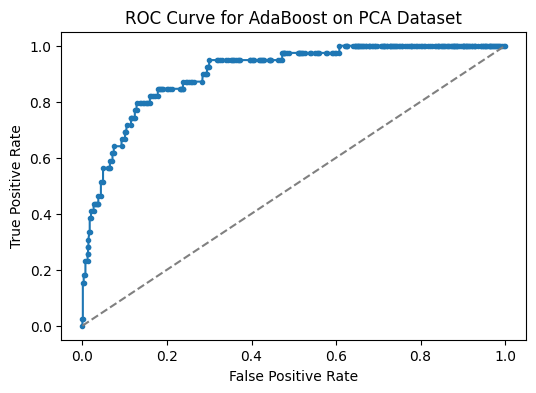

AUC: 0.9028


In [270]:
probas = adaboost_pca.predict_proba(X_test_pca)
fpr, tpr, thresholds = roc_curve(y_test, probas)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, marker='.')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Add diagonal line for reference
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for AdaBoost on PCA Dataset')
plt.show()

print(f"AUC: {auc(fpr, tpr):.4f}")


### 6.1 Evaluation Of The QuantumEnhancedAdaBoost


In [271]:
test_predictions_pca_hybrid = quantum_enhanced_adaboost_pca.predict(X_test_pca, X_test_pca_angle)

hybrid_accuracy_pca = (test_predictions_pca_hybrid == y_test).mean()

hybrid_precision_pca = precision_at_fixed_recall(y_test, quantum_enhanced_adaboost_pca.predict_proba(X_test_pca, X_test_pca_angle), target_recall=0.83)

results_hybrid = pd.DataFrame({
    "PCA": [hybrid_accuracy_pca, hybrid_precision_pca],
}, index=["Accuracy", "Precision @ Recall=0.83"])

results_hybrid

,PCA
Accuracy,0.847507
Precision @ Recall=0.83,0.186441


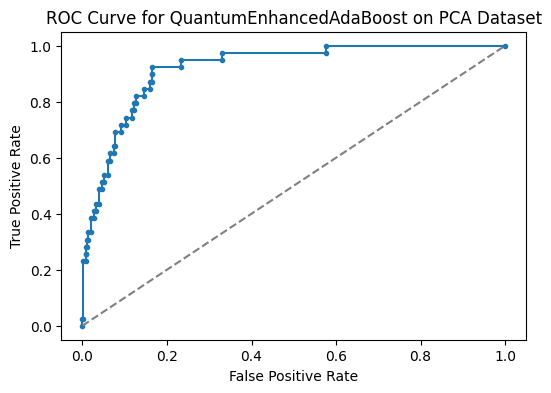

AUC: 0.9209


In [272]:
probas = quantum_enhanced_adaboost_pca.predict_proba(X_test_pca, X_test_pca_angle)
fpr, tpr, thresholds = roc_curve(y_test, probas)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, marker='.')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Add diagonal line for reference
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for QuantumEnhancedAdaBoost on PCA Dataset')
plt.show()

print(f"AUC: {auc(fpr, tpr):.4f}")

### 6.2 Final Look At Our Models


In [273]:
num_positives_pca = (test_predictions_pca_adaboost == 1.0).sum()
print(f"Number of samples predicted as positive (bankrupt) by the PCA AdaBoost model: {num_positives_pca}")
num_positives_pca = (test_predictions_pca_hybrid == 1.0).sum()
print(f"Number of samples predicted as positive (bankrupt) by the PCA hybrid model: {num_positives_pca}")
print(f"Total number of positive samples in test set: {(y_test == 1.0).sum()}")

total_samples = len(y_test)
print(f"Total number of samples in test set: {total_samples}")

Number of samples predicted as positive (bankrupt) by the PCA AdaBoost model: 126
Number of samples predicted as positive (bankrupt) by the PCA hybrid model: 183
Total number of positive samples in test set: 39
Total number of samples in test set: 1023


## 7 Conclusion

We have seen, through the hybrid model's weights, that this model indeed gives more importance to submodels that reach high precision at 83% recall on the validation set. We see now how this reflects on the test set; a lower accuracy and a tendency to over-predict the positive class, but a higher precision at 83% recall and a higher Area Under the Curve (AUC). 

We can now justify the use of a QuantumEnhancedAdaBoost optimized on the precision for a given recall based on which metric is most important for a given task. We have also seen how oversampling can help in imbalanced dataset settings.